# CS215 SP26 Final Project - Hana Nandawula-Bunnya

##Introduction:
###In this project, I analyzed a large dataset of Spotify songs to understand what makes a song popular. Music streaming platforms like Spotify collect detailed audio features for each track, such as danceability, energy, tempo, and valence. The goal of this analysis is to explore relationships between these features and song popularity, identify patterns across genres, and use clustering to group similar types of music.


## Dataset Description

The dataset contains information about thousands of Spotify tracks, including both metadata (artist, genre, track name) and audio features computed by Spotify's analysis algorithms.

Key variables include:
- popularity
- danceability
- energy
- tempo
- genre
- valence



## Data Source

The dataset used in this project was obtained from Kaggle:

https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset

The dataset contains Spotify track information and computed audio features used for music analysis.

## Research Questions

1. Which Spotify audio features are most associated with song popularity?
2. Do more danceable or energetic songs tend to be more popular?
3. How do musical characteristics differ across genres?
4. Can clustering techniques identify natural groupings of songs based on audio features?

##Setup + Loading the Data

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/spotify-tracks-dataset.csv")

# Preview dataset
df.head()

#Dataset dimensions
df.shape

(114000, 22)

In [27]:
#where I got this data from: Kaggle, from:https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset?select=spotify-tracks-dataset.csv

## Data Cleaning Notes: Basic Cleaning
The dataset required minimal cleaning. One unnecessary index column (“Unnamed: 0”) was removed. Missing values were dropped to ensure clean analysis. After this step, the dataset was ready for exploration and visualization.



In [28]:
# Drop useless column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Check missing values
print(df.isnull().sum())

# Optional: drop rows with missing values (safe for tonight)
df = df.dropna()

Unnamed: 0.1        0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


# Correlation Heatmap

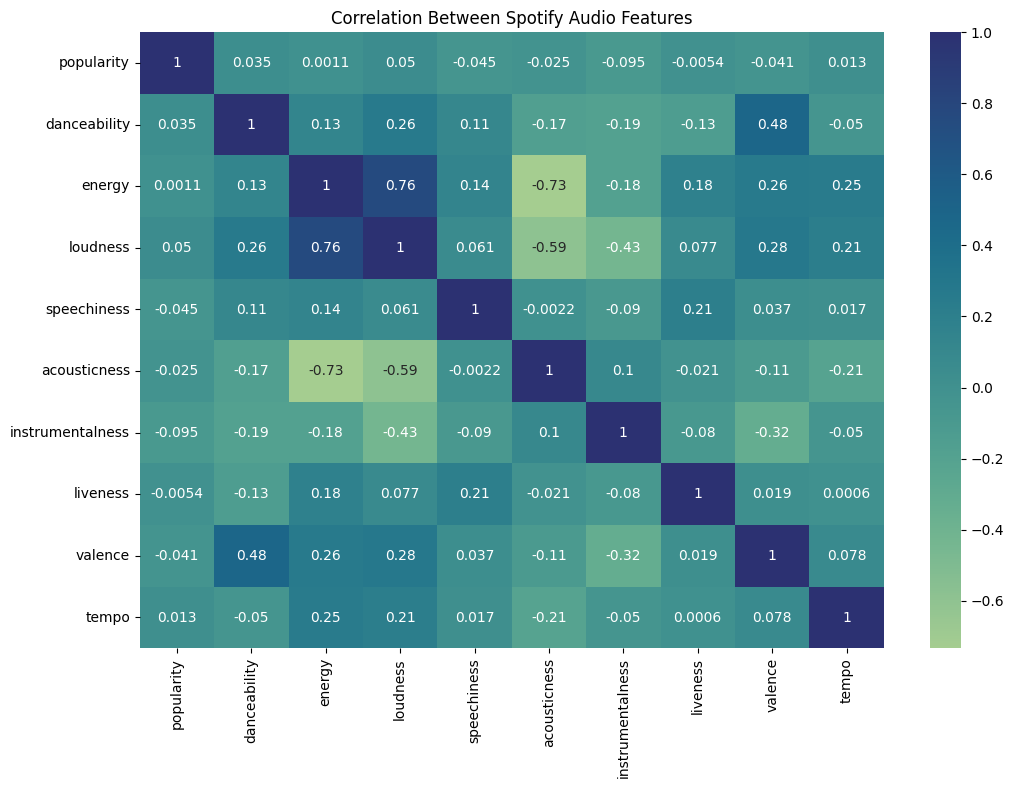

In [29]:
plt.figure(figsize=(12, 8))

numeric_cols = [
    "popularity", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo"
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="crest")
plt.title("Correlation Between Spotify Audio Features")
plt.show()

# Correlation Heatmap Interpretation:
The correlation heatmap shows relationships between different audio features and song popularity. We see in this visualization that no single feature strongly determines popularity, but some weak relationships exist. For example, energy and loudness tend to be positively correlated, while acousticness tends to be negatively correlated with energy.


# Scatterplot of Popularity vs Danceability

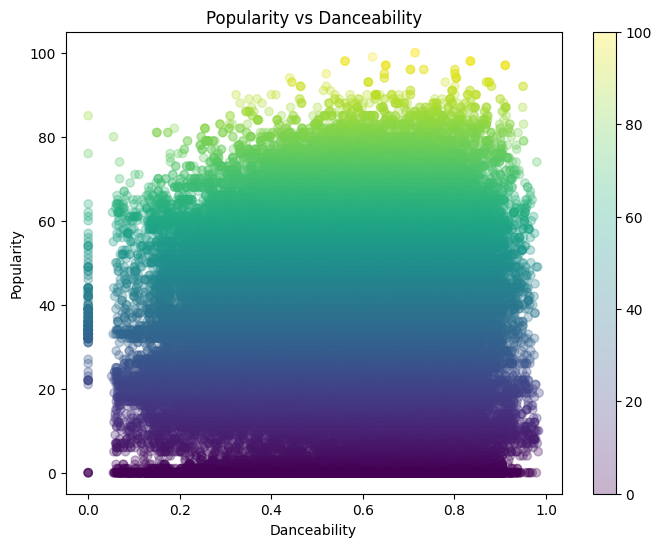

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(df["danceability"], df["popularity"], alpha=0.3, c=df["popularity"], cmap='viridis')
plt.colorbar()
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Popularity vs Danceability")
plt.show()

#Scatterplot Interpretation (Popularity vs Danceability):
This visualization explores whether more danceable songs tend to be more popular. The relationship appears weak, suggesting that while danceability may contribute to popularity, it is not the only determining factor.

# Second scatterplot on popularity vs energy

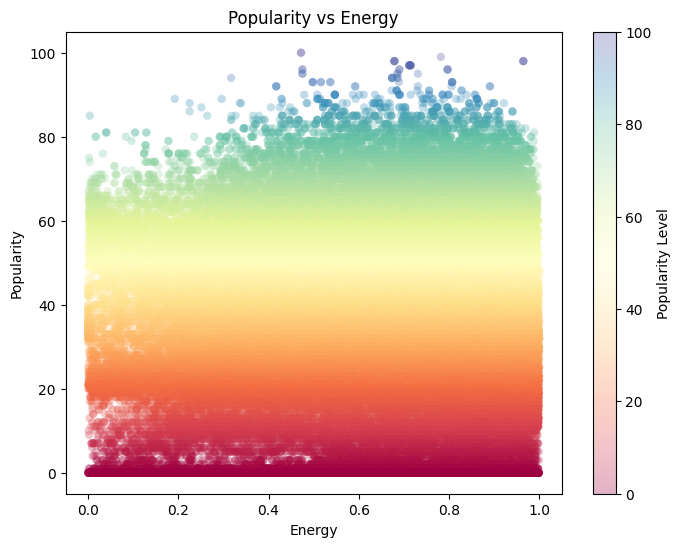

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(df["energy"], df["popularity"], alpha=0.3, c=df["popularity"], cmap="Spectral", edgecolors="none")
plt.colorbar(label="Popularity Level")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Popularity vs Energy")
plt.show()

#Scatterplot Interpretation (Popularity vs Energy):
A similar analysis between energy and popularity shows that higher energy songs are slightly more likely to have higher popularity, but the trend is not strongly linear.

# Genre Comparison (Bar Chart)

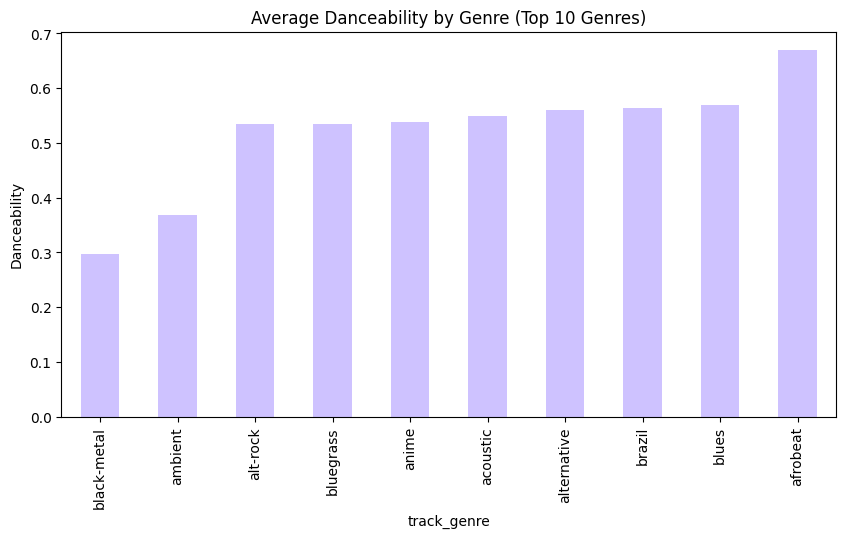

In [32]:
top_genres = df["track_genre"].value_counts().head(10).index
genre_df = df[df["track_genre"].isin(top_genres)]

genre_means = genre_df.groupby("track_genre")["danceability"].mean()

plt.figure(figsize=(10,5))
genre_means.sort_values().plot(kind="bar", color="#cec2ff")
plt.title("Average Danceability by Genre (Top 10 Genres)")
plt.ylabel("Danceability")
plt.show()

# Genre Bar Chart Analysis:
This analysis compares average audio features across the top genres in the dataset. Different genres show distinct musical characteristics, such as varying levels of danceability and energy. This highlights how genre influences the overall structure of music.

# KMeans on original feature space vs PCA-reduced space for comparison

## K-means clustering (extra technique)
### Why Clustering?

While correlation and scatterplots help analyze relationships between individual variables, clustering allows for exploration of broader patterns in the dataset by grouping songs based on overall similarity across multiple audio features.

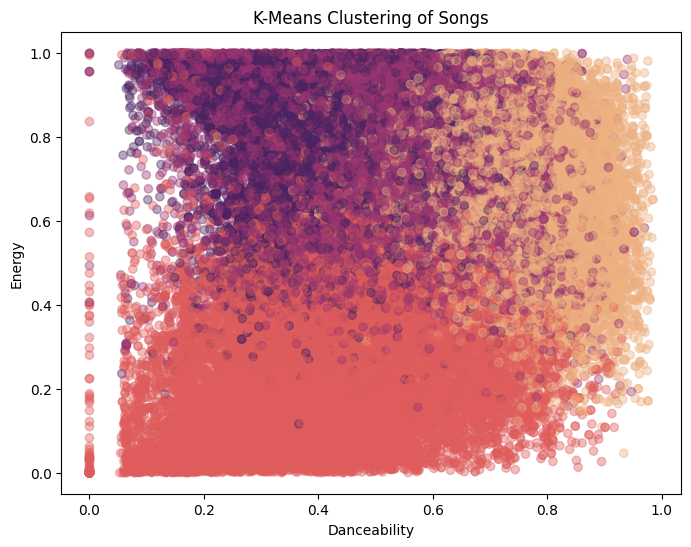

In [36]:
from sklearn.cluster import KMeans

features = df[[
    "danceability", "energy", "valence",
    "acousticness", "tempo"
]]

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled_features)

# Visualize clusters (2D projection)
plt.figure(figsize=(8,6))

plt.scatter(df["danceability"], df["energy"],
            c=df["cluster"], cmap="flare", alpha=0.4)

plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("K-Means Clustering of Songs")
plt.show()

# K-Means Clustering (New Technique):
To further explore patterns in the data, I applied K-Means clustering to group songs based on their audio features.
The algorithm grouped songs into clusters based on similarities in danceability, energy, valence, acousticness, and tempo. The resulting clusters represent different “types” of songs, such as high-energy tracks versus more calm and acoustic tracks.


#Principal Component Analysis (PCA) (New Technique)

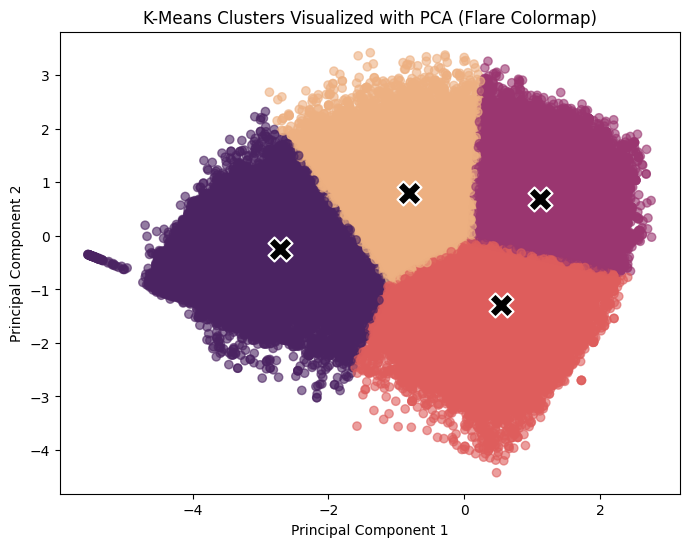

In [37]:
from sklearn.decomposition import PCA

# -----------------------------
# 1. Select features
# -----------------------------
features = df[[
    "danceability", "energy", "valence",
    "acousticness", "tempo"
]]

# -----------------------------
# 2. Standardize
# -----------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# -----------------------------
# 3. PCA (reduce to 2D)
# -----------------------------
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

df["PC1"] = components[:, 0]
df["PC2"] = components[:, 1]

# -----------------------------
# 4. K-Means
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(components)

centroids = kmeans.cluster_centers_

# -----------------------------
# 5. Plot (flare colormap + enhanced centroids)
# -----------------------------
plt.figure(figsize=(8,6))

# song points
plt.scatter(df["PC1"], df["PC2"],
            c=df["cluster"], cmap="flare", alpha=0.6)

# centroids (enhanced visibility)
plt.scatter(centroids[:,0], centroids[:,1],
            c="black", s=300, marker="X", edgecolors="white", linewidths=1.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA (Flare Colormap)")

plt.show()

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a set of possibly correlated variables into a smaller number of uncorrelated variables called principal components. In this project, PCA was applied to Spotify audio features such as danceability, energy, valence, tempo, and acousticness to reduce the dataset to two dimensions. This made it possible to visualize the clustering structure produced by K-Means more clearly. Because many audio features are correlated, PCA helps summarize the main variation in the dataset while preserving important patterns for analysis and visualization. Reducing the dimensionality of the data also simplifies interpretation of relationships between songs and clusters. This technique was learned through the DataCamp “Unsupervised Learning in Python” module and then adapted for use in this project alongside K-Means clustering.

## Reflection
One of the most surprising findings from this project was that no single audio feature strongly determines song popularity. While some weak relationships exist, popularity appears to depend on many interacting factors rather than one dominant characteristic.

The most challenging part of the project was working with high-dimensional audio feature data and deciding how to meaningfully visualize patterns within it. Applying PCA alongside K-Means clustering was especially helpful in simplifying the dataset and making the clustering structure easier to interpret in two dimensions. This process also helped deepen my understanding of how dimensionality reduction can improve the interpretability of machine learning results.

## Conclusion:
This project explored how Spotify audio features relate to song popularity and musical similarity. Overall, the analysis shows that song popularity is influenced by multiple weakly related audio features rather than a single dominant factor. While no single feature strongly predicts popularity, meaningful patterns emerge across genres and clusters of songs with similar musical characteristics. Additionally, clustering results show that songs naturally form distinct groups based on their overall musical properties. Combining PCA with K-Means clustering helped simplify the data and made these relationships easier to visualize and interpret.


##Additional Notes: AI Usage/Citations
- Google Gemini was used to help customize visualization colors and colormaps in matplotlib.
- Coolors.co was used for color palette inspiration.
- ChatGPT was used for debugging, organization, and explanation support.